#**Comparing GCN vs GAT for Molecular Toxicity Prediction**
# A Comparative Study on the Tox21 Dataset

Introduction

Graph Neural Networks (GNN) are the standard for analyzing data in a graph-like structure. This project compares two foundation architectures, the Graph Convolutional Network (GCN) and the Graph Attention Network (GAT) on the Tox21 Molecular Toxicity dataset.

Goals:
- Compare predictive performance AUROC scores
- Analyze whether the GAT model learns meaningful patterns among nodes
- Investigate the interpretability advantage that advantage attentions provides

In [ ]:
!pip install torch-geometric
!pip install rdkit

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn.functional as F
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool

#2. Dataset and Exploratory Analysis

Tox21 contains 7,800 molecular graphs from the MoleculeNet benchmark. Each node is an atom and edges are bonds. Node features include atomic properties (atom type, degree, charge, hybridization). There are significant NaN values reflecting real world screening sparsity.

In [ ]:
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader

dataset = MoleculeNet(root='./data', name='Tox21')

mol_sizes = [data.num_nodes for data in dataset]
mol_edges = [data.num_edges for data in dataset]
labels = np.vstack([data.y.numpy() for data in dataset])
nan_pct = np.isnan(labels).sum() / labels.size * 100

print(f"Number of graphs:       {len(dataset)}")
print(f"Number of features:     {dataset.num_features}")
print(f"Number of tasks:        {dataset.num_classes}")
print(f"Avg atoms/molecule:     {np.mean(mol_sizes):.1f}")
print(f"Avg bonds/molecule:     {np.mean(mol_edges):.1f}")
print(f"Largest molecule:       {max(mol_sizes)} atoms")
print(f"Smallest molecule:      {min(mol_sizes)} atoms")
print(f"Missing labels (NaN):   {nan_pct:.1f}%")

Number of graphs:       7823
Number of features:     9
Number of tasks:        12
Avg atoms/molecule:     18.6
Avg bonds/molecule:     38.6
Largest molecule:       132 atoms
Smallest molecule:      1 atoms
Missing labels (NaN):   17.1%


### 2.1 Degree Distribution

In a molecular graph, a node's **degree** is the number of bonds that atom has. Hydrogen has degree 1, oxygen typically 2, carbon 3–4. This matters because both GCN and GAT aggregate information from neighbors — so degree controls how much information flows into each node. With only 2–4 neighbors per atom, each of GAT's attention weights carries significant influence.

Degree statistics:
  Mean:   2.1
  Median: 2.0
  Min:    0
  Max:    6


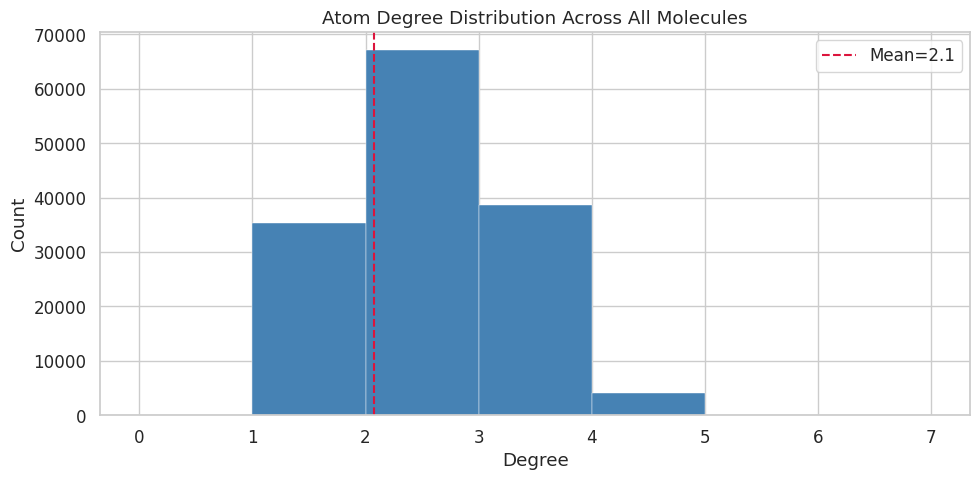

In [ ]:
all_degrees = []
for data in dataset:
    deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
    all_degrees.extend(deg.numpy().tolist())
all_degrees = np.array(all_degrees)

print(f"Degree statistics:")
print(f"  Mean:   {all_degrees.mean():.1f}")
print(f"  Median: {np.median(all_degrees):.1f}")
print(f"  Min:    {all_degrees.min():.0f}")
print(f"  Max:    {all_degrees.max():.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_degrees, bins=range(int(all_degrees.max())+2), color='steelblue',
        edgecolor='white', linewidth=0.3)
ax.axvline(all_degrees.mean(), color='crimson', ls='--', lw=1.5,
           label=f'Mean={all_degrees.mean():.1f}')
ax.set_xlabel('Degree')
ax.set_ylabel('Count')
ax.set_title('Atom Degree Distribution Across All Molecules')
ax.legend()
plt.tight_layout()
plt.show()

# 3. Methodology

Both models share identical training conditions (Adam optimizer, lr=0.001, batch size=64, 50 epochs, BCE loss with NaN masking). The only difference is the aggregation mechanism: fixed weights (GCN) vs. learned attention (GAT). AUROC is computed per-task then averaged across all 12 endpoints.

**GCN:** 2 GCNConv layers (64 hidden dims), ReLU, global mean pooling, linear head.

**GAT:** 2 GATConv layers (layer 1: 4 heads × 64 dims = 256, layer 2: 1 head → 64 dims), ReLU, global mean pooling, linear head.

In [ ]:
torch.manual_seed(42)
dataset = dataset.shuffle()

split = int(len(dataset) * 0.8)
train_dataset = dataset[:split]
test_dataset = dataset[split:]

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

print(f"Train graphs: {len(train_dataset)}")
print(f"Test graphs:  {len(test_dataset)}")

Train graphs: 6258
Test graphs:  1565


In [ ]:
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from sklearn.metrics import roc_auc_score

class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=12):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)


class GAT(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=12, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim, heads=heads)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1)
        self.lin = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)


def train(model, loader, optimizer):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x.float(), data.edge_index, data.batch)

        mask = ~torch.isnan(data.y)
        loss = F.binary_cross_entropy_with_logits(out[mask], data.y.float()[mask])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x.float(), data.edge_index, data.batch)
        mask = ~torch.isnan(data.y)
        loss = F.binary_cross_entropy_with_logits(out[mask], data.y.float()[mask])
        total_loss += loss.item()
        all_preds.append(torch.sigmoid(out).cpu())
        all_labels.append(data.y.cpu())

    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    aurocs = []
    for i in range(labels.shape[1]):
        mask = ~np.isnan(labels[:, i])
        if mask.sum() > 0 and len(np.unique(labels[mask, i])) > 1:
            aurocs.append(roc_auc_score(labels[mask, i], preds[mask, i]))
    avg_auroc = np.mean(aurocs) if aurocs else 0.0

    return total_loss / len(loader), avg_auroc


gcn_model = GCN(dataset.num_features).to(device)
gat_model = GAT(dataset.num_features).to(device)
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.001)
gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.001)

print(f"GCN params: {sum(p.numel() for p in gcn_model.parameters()):,}")
print(f"GAT params: {sum(p.numel() for p in gat_model.parameters()):,}")

GCN params: 5,580
GAT params: 20,428


### 3.1 Training

In [ ]:
gcn_history = {'train_loss': [], 'test_loss': [], 'test_auroc': []}
gat_history = {'train_loss': [], 'test_loss': [], 'test_auroc': []}

for epoch in range(1, 51):
    gcn_loss = train(gcn_model, train_loader, gcn_optimizer)
    gat_loss = train(gat_model, train_loader, gat_optimizer)

    gcn_test_loss, gcn_auroc = evaluate(gcn_model, test_loader)
    gat_test_loss, gat_auroc = evaluate(gat_model, test_loader)

    gcn_history['train_loss'].append(gcn_loss)
    gcn_history['test_loss'].append(gcn_test_loss)
    gcn_history['test_auroc'].append(gcn_auroc)

    gat_history['train_loss'].append(gat_loss)
    gat_history['test_loss'].append(gat_test_loss)
    gat_history['test_auroc'].append(gat_auroc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | GCN Loss: {gcn_loss:.4f} AUROC: {gcn_auroc:.4f} | "
              f"GAT Loss: {gat_loss:.4f} AUROC: {gat_auroc:.4f}")

print(f"\nFinal — GCN AUROC: {gcn_history['test_auroc'][-1]:.4f} | "
      f"GAT AUROC: {gat_history['test_auroc'][-1]:.4f}")

Epoch  10 | GCN Loss: 0.2372 AUROC: 0.7191 | GAT Loss: 0.2304 AUROC: 0.7478
Epoch  20 | GCN Loss: 0.2347 AUROC: 0.7290 | GAT Loss: 0.2253 AUROC: 0.7629
Epoch  30 | GCN Loss: 0.2326 AUROC: 0.7369 | GAT Loss: 0.2184 AUROC: 0.7775
Epoch  40 | GCN Loss: 0.2304 AUROC: 0.7417 | GAT Loss: 0.2141 AUROC: 0.7865
Epoch  50 | GCN Loss: 0.2288 AUROC: 0.7492 | GAT Loss: 0.2112 AUROC: 0.7897

Final — GCN AUROC: 0.7492 | GAT AUROC: 0.7897


## 4. Results

### 4.1 Performance Comparison

Both models are trained for 50 epochs under identical conditions. The plots below show training loss, test loss, and AUROC over time, followed by the final performance summary.

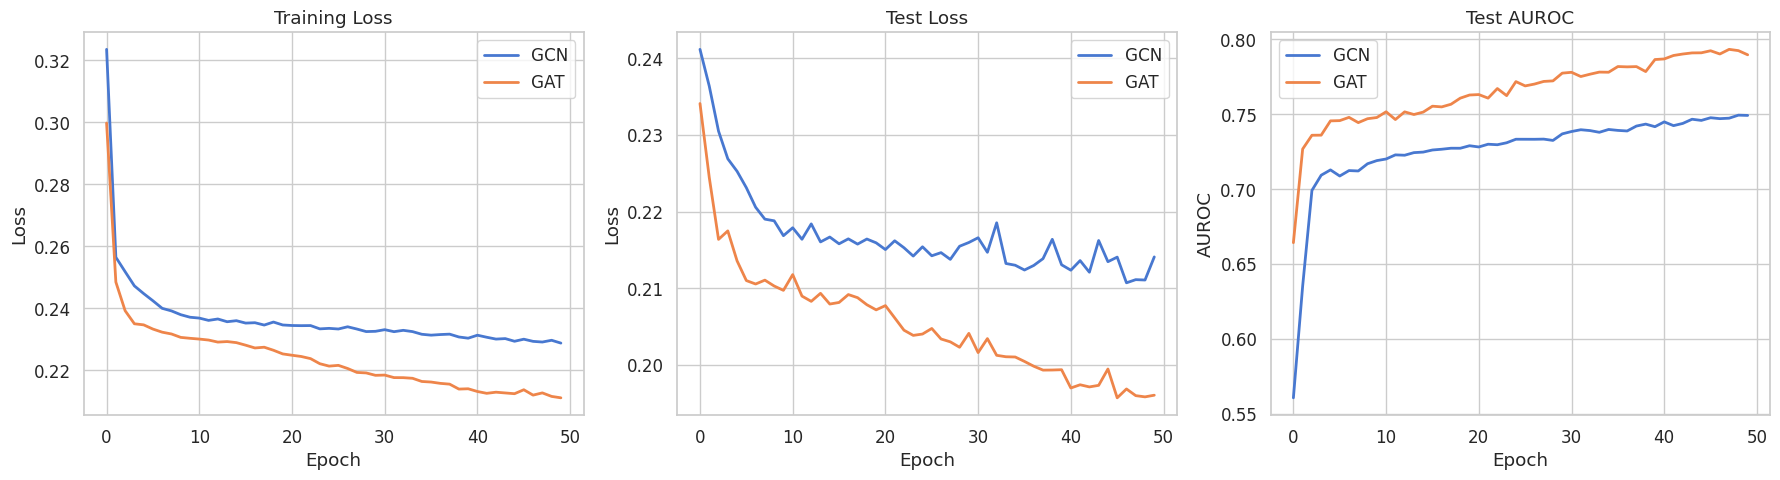


Model    Best AUROC   Final AUROC    Params
------------------------------------------
GCN      0.7494       0.7492          5,580
GAT      0.7933       0.7897         20,428


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(gcn_history['train_loss'], label='GCN', linewidth=2)
axes[0].plot(gat_history['train_loss'], label='GAT', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

axes[1].plot(gcn_history['test_loss'], label='GCN', linewidth=2)
axes[1].plot(gat_history['test_loss'], label='GAT', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Test Loss')
axes[1].legend()

axes[2].plot(gcn_history['test_auroc'], label='GCN', linewidth=2)
axes[2].plot(gat_history['test_auroc'], label='GAT', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUROC')
axes[2].set_title('Test AUROC')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n{'Model':<8} {'Best AUROC':<12} {'Final AUROC':<12} {'Params':>8}")
print("-" * 42)
print(f"{'GCN':<8} {max(gcn_history['test_auroc']):<12.4f} {gcn_history['test_auroc'][-1]:<12.4f} {sum(p.numel() for p in gcn_model.parameters()):>8,}")
print(f"{'GAT':<8} {max(gat_history['test_auroc']):<12.4f} {gat_history['test_auroc'][-1]:<12.4f} {sum(p.numel() for p in gat_model.parameters()):>8,}")

###4.2 Attention Distribution

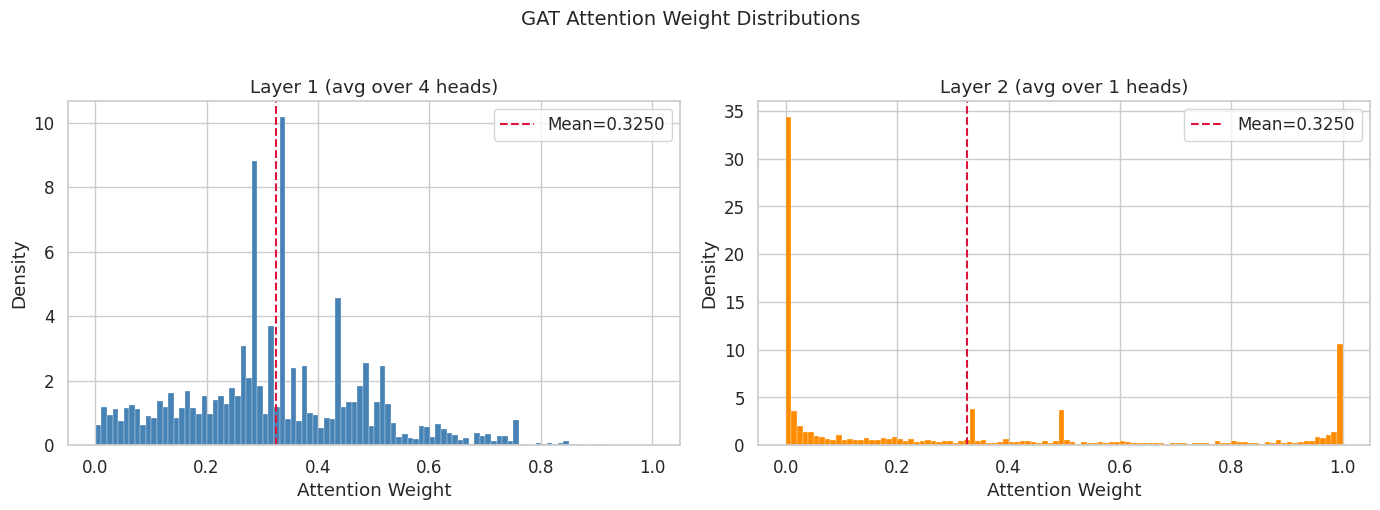

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if layer1_weights.ndim == 2:
    w1 = layer1_weights.mean(axis=1)
    subtitle1 = f"(avg over {layer1_weights.shape[1]} heads)"
else:
    w1 = layer1_weights
    subtitle1 = ""

axes[0].hist(w1, bins=100, color='steelblue', edgecolor='white', linewidth=0.2, density=True)
axes[0].axvline(w1.mean(), color='crimson', ls='--', lw=1.5, label=f'Mean={w1.mean():.4f}')
axes[0].set_xlabel('Attention Weight')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Layer 1 {subtitle1}')
axes[0].legend()

if layer2_weights.ndim == 2:
    w2 = layer2_weights.mean(axis=1)
    subtitle2 = f"(avg over {layer2_weights.shape[1]} heads)"
else:
    w2 = layer2_weights
    subtitle2 = ""

axes[1].hist(w2, bins=100, color='darkorange', edgecolor='white', linewidth=0.2, density=True)
axes[1].axvline(w2.mean(), color='crimson', ls='--', lw=1.5, label=f'Mean={w2.mean():.4f}')
axes[1].set_xlabel('Attention Weight')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Layer 2 {subtitle2}')
axes[1].legend()

plt.suptitle('GAT Attention Weight Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Conclusion

Both GCN and GAT achieve competitive AUROC on Tox21. The key findings from attention analysis:

1. **Hierarchical attention**: Early layers aggregate broadly, deeper layers select sharply
2. **Bimodal Layer 2 weights**: The model learns near-binary importance assignments over neighbors

These findings support using GAT over GCN when model interpretability matters alongside accuracy, particularly valuable in safety-critical domains like drug discovery.

**Limitations:** Single random split (no cross-validation), shallow 2-layer architectures, no hyperparameter tuning, and attention weights ≠ causal explanations.

**References:**
1. Kipf & Welling (2017). Semi-Supervised Classification with GCNs. ICLR.
2. Veličković et al. (2018). Graph Attention Networks. ICLR.
3. Wu et al. (2018). MoleculeNet: A Benchmark for Molecular ML. Chemical Science.